In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

BASE_PATH = "ass1"
print("Files in folder:")


Files in folder:


In [6]:
# ---- EDIT THESE TWO FILENAMES BASED ON YOUR FOLDER LISTING ----
STOCK_INFO_FILE = os.path.join( "stock_categories.csv")     # name/sector mapping
RETURNS_FILE    = os.path.join("daily_returns.csv")    # daily returns (3 years)

# Load stock info
stock_info = pd.read_csv(STOCK_INFO_FILE)
print("stock_info shape:", stock_info.shape)
display(stock_info.head())

# Load returns
ret = pd.read_csv(RETURNS_FILE)

# If your returns file has a date column, try to parse it:
date_cols = [c for c in ret.columns if "date" in c.lower()]
if len(date_cols) > 0:
    ret[date_cols[0]] = pd.to_datetime(ret[date_cols[0]])
    ret = ret.sort_values(date_cols[0]).set_index(date_cols[0])

print("returns shape:", ret.shape)
display(ret.head())


stock_info shape: (30, 3)


,Category,Symbol,Company Name
0,Banking & Finance,HDFCBANK,HDFC Bank
1,Banking & Finance,ICICIBANK,ICICI Bank
2,Banking & Finance,SBIN,State Bank of India
3,Information Tech,TCS,TCS
4,Information Tech,INFY,Infosys


returns shape: (739, 30)


,HDFCBANK,ICICIBANK,SBIN,TCS,INFY,HCLTECH,BAJAJ-AUTO,M&M,MARUTI,HINDUNILVR,...,HINDALCO,LT,ULTRACEMCO,ADANIPORTS,BHARTIARTL,TATACOMM,INDUSTOWER,TITAN,DMART,TRENT
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,-1.4869,1.1734,0.1422,1.5271,2.1049,1.5458,-0.5405,0.0259,1.1552,2.3541,...,-0.5237,-0.0303,0.3676,-6.6041,1.1247,0.9439,-1.1777,-1.6113,-1.3643,-0.4441
2023-02-03,3.4584,0.6877,3.0487,0.6329,0.9882,-0.3001,1.6316,2.6324,0.8134,0.5276,...,-1.2355,1.0094,0.3007,7.8711,1.9479,1.0463,0.7010,6.7155,-0.9292,2.0692
2023-02-06,-0.4250,-1.1692,0.2205,-0.6418,-1.8476,-0.0392,-0.0896,-0.8646,-0.3836,-0.4209,...,-2.6760,-0.4823,-0.8617,9.3415,-0.4603,2.5724,12.8089,-0.2071,-0.8313,-0.4492
2023-02-07,0.1483,-0.1113,0.3117,0.3642,-0.4746,-1.5231,0.7885,-0.6759,-1.6339,-1.3801,...,-3.9790,0.4267,-0.7780,1.4117,-0.4245,-1.9475,-1.0491,-0.4516,-0.0174,-1.3779
2023-02-08,-0.0121,0.7446,0.4844,1.3693,1.7985,1.4846,0.0219,0.4646,0.8246,-0.7074,...,1.6180,-1.5910,2.5248,8.3341,-1.3742,0.9039,0.4054,0.8112,0.5144,1.8876


In [7]:
ret = ret.copy()

# If values look like percentages (e.g., 1.2 meaning 1.2%), convert to decimals
# Heuristic: if typical absolute returns > 1, it's probably % not decimal
sample_abs = ret.select_dtypes(include=[np.number]).stack().abs().median()
print("Median |return| sample:", sample_abs)

if sample_abs > 1:
    print("Looks like % returns. Converting by /100 ...")
    ret = ret / 100.0

# Keep only numeric columns (tickers)
ret = ret.select_dtypes(include=[np.number]).dropna(how="all")
ret = ret.dropna()  # simplest: drop any rows with missing values

print("Cleaned returns shape:", ret.shape)


Median |return| sample: 0.76265
Cleaned returns shape: (739, 30)


In [9]:
# ---- OPTION A: MANUAL ----
# Put your chosen 10 tickers EXACTLY as they appear in ret.columns
selected_tickers = None
# selected_tickers = ["TICK1","TICK2","TICK3","TICK4","TICK5","TICK6","TICK7","TICK8","TICK9","TICK10"]


In [10]:
# ---- OPTION B: AUTO GREEDY (low average correlation) ----
def greedy_low_corr_selection(returns_df, n_select=10):
    corr = returns_df.corr().fillna(0)
    tickers = corr.columns.tolist()

    # Start with the least correlated "overall" stock (lowest average |corr|)
    avg_abs = corr.abs().mean(axis=1)
    chosen = [avg_abs.idxmin()]

    # Add stocks that minimize average |corr| to chosen set
    while len(chosen) < n_select:
        remaining = [t for t in tickers if t not in chosen]
        scores = []
        for t in remaining:
            score = corr.loc[t, chosen].abs().mean()  # lower is better
            scores.append((score, t))
        scores.sort()
        chosen.append(scores[0][1])
    return chosen

if selected_tickers is None:
    selected_tickers = greedy_low_corr_selection(ret, n_select=10)

print("Selected 10 tickers:", selected_tickers)
returns_10 = ret[selected_tickers].copy()
print("returns_10 shape:", returns_10.shape)


Selected 10 tickers: ['HINDUNILVR', 'SBIN', 'CIPLA', 'DMART', 'INFY', 'BAJAJ-AUTO', 'INDUSTOWER', 'ITC', 'HDFCBANK', 'SUNPHARMA']
returns_10 shape: (739, 10)


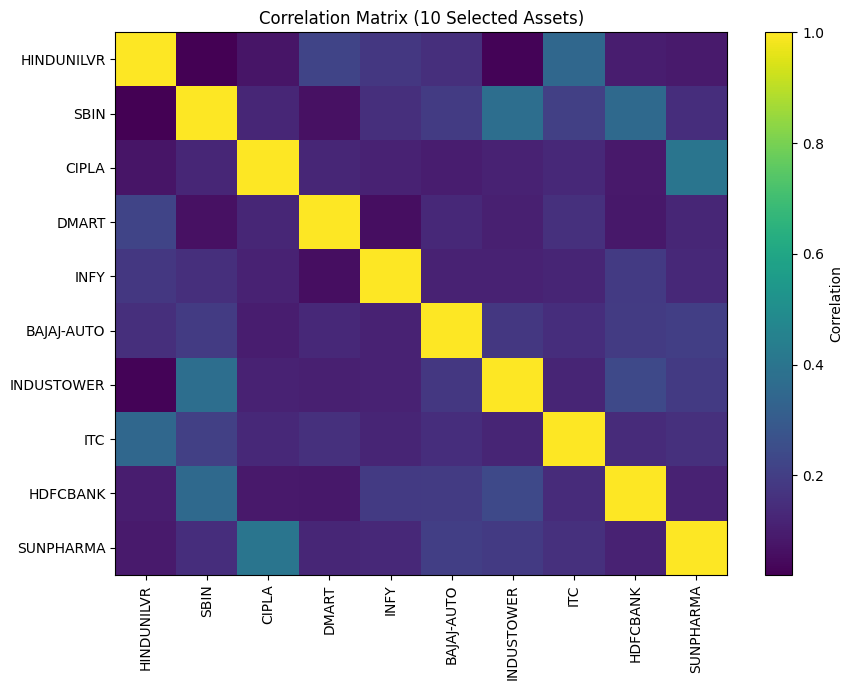

Avg pairwise corr: 0.15390898867949251
Avg |pairwise corr|: 0.15390898867949251


In [11]:
corr10 = returns_10.corr()

plt.figure(figsize=(9,7))
plt.imshow(corr10.values, aspect='auto')
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_tickers)), selected_tickers, rotation=90)
plt.yticks(range(len(selected_tickers)), selected_tickers)
plt.title("Correlation Matrix (10 Selected Assets)")
plt.tight_layout()
plt.show()

avg_pair_corr = corr10.where(~np.eye(len(selected_tickers), dtype=bool)).stack().mean()
avg_abs_pair_corr = corr10.where(~np.eye(len(selected_tickers), dtype=bool)).stack().abs().mean()
print("Avg pairwise corr:", avg_pair_corr)
print("Avg |pairwise corr|:", avg_abs_pair_corr)


In [12]:
# Use last ~1 year (252 trading days) as test
TRADING_DAYS = 252
split_n = TRADING_DAYS

train = returns_10.iloc[:-split_n].copy()
test  = returns_10.iloc[-split_n:].copy()

print("Train:", train.index.min(), "->", train.index.max(), "n=", len(train))
print("Test :", test.index.min(),  "->", test.index.max(),  "n=", len(test))


Train: 2023-02-02 00:00:00 -> 2025-01-24 00:00:00 n= 487
Test : 2025-01-27 00:00:00 -> 2026-01-30 00:00:00 n= 252


In [13]:
RF_ANNUAL = 0.065

mu_d = train.mean().values
cov_d = train.cov().values

mu = mu_d * TRADING_DAYS
cov = cov_d * TRADING_DAYS

# tiny stabilizer
cov = cov + 1e-10 * np.eye(len(selected_tickers))

def perf_from_weights(w, mu_annual, cov_annual, rf_annual=RF_ANNUAL):
    r = float(w @ mu_annual)
    v = float(np.sqrt(w @ cov_annual @ w))
    s = (r - rf_annual) / v if v > 0 else np.nan
    return r, v, s

print("mu (annual) sample:", mu[:5])
print("cov (annual) shape:", cov.shape)


mu (annual) sample: [-0.75910472 22.87414867 19.91136345  3.80256099 15.59486735]
cov (annual) shape: (10, 10)


In [14]:
def monte_carlo_frontier(mu_annual, cov_annual, rf_annual, n_portfolios=20000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(mu_annual)

    W = np.zeros((n_portfolios, n))
    rets = np.zeros(n_portfolios)
    vols = np.zeros(n_portfolios)
    sharpes = np.zeros(n_portfolios)

    for i in range(n_portfolios):
        w = rng.random(n)
        w = w / w.sum()  # long-only, sum=1
        W[i] = w

        r = float(w @ mu_annual)
        v = float(np.sqrt(w @ cov_annual @ w))
        s = (r - rf_annual) / v if v > 0 else np.nan

        rets[i], vols[i], sharpes[i] = r, v, s

    idx_gmv = int(np.argmin(vols))
    idx_ms  = int(np.nanargmax(sharpes))

    return W, rets, vols, sharpes, idx_gmv, idx_ms

N_PORTFOLIOS = 20000  # >=10000 required
W, rets_mc, vols_mc, sharpes_mc, idx_gmv_mc, idx_ms_mc = monte_carlo_frontier(mu, cov, RF_ANNUAL, N_PORTFOLIOS)

w_gmv_mc = W[idx_gmv_mc]
w_ms_mc  = W[idx_ms_mc]

print("MC GMV  (ann_ret, ann_vol, sharpe):", perf_from_weights(w_gmv_mc, mu, cov))
print("MC MaxS (ann_ret, ann_vol, sharpe):", perf_from_weights(w_ms_mc,  mu, cov))


MC GMV  (ann_ret, ann_vol, sharpe): (15.727209927825161, 10.203748570583821, 1.5349466737133672)
MC MaxS (ann_ret, ann_vol, sharpe): (32.24038433355871, 12.844764035886417, 2.5049416434327116)


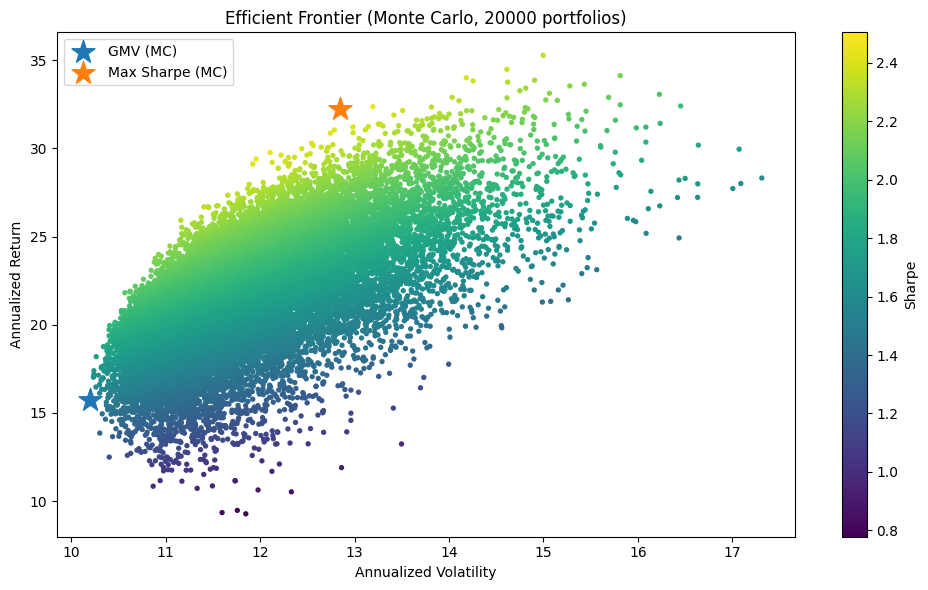

In [15]:
plt.figure(figsize=(10,6))
sc = plt.scatter(vols_mc, rets_mc, c=sharpes_mc, s=8)
plt.scatter(vols_mc[idx_gmv_mc], rets_mc[idx_gmv_mc], marker="*", s=300, label="GMV (MC)")
plt.scatter(vols_mc[idx_ms_mc],  rets_mc[idx_ms_mc],  marker="*", s=300, label="Max Sharpe (MC)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title(f"Efficient Frontier (Monte Carlo, {N_PORTFOLIOS} portfolios)")
plt.colorbar(sc, label="Sharpe")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
wt_mc = pd.DataFrame({
    "Stock": selected_tickers,
    "GMV (MC)": w_gmv_mc,
    "MaxSharpe (MC)": w_ms_mc
})
wt_mc["Diff (MS - GMV)"] = wt_mc["MaxSharpe (MC)"] - wt_mc["GMV (MC)"]
wt_mc = wt_mc.sort_values("MaxSharpe (MC)", ascending=False)

display(wt_mc)
print("Sum GMV(MC):", wt_mc["GMV (MC)"].sum(), " Sum MS(MC):", wt_mc["MaxSharpe (MC)"].sum())


,Stock,GMV (MC),MaxSharpe (MC),Diff (MS - GMV)
9,SUNPHARMA,0.159930,0.262294,0.102364
5,BAJAJ-AUTO,0.062507,0.252568,0.190061
6,INDUSTOWER,0.007019,0.121910,0.114891
2,CIPLA,0.102056,0.117472,0.015416
0,HINDUNILVR,0.208680,0.082535,-0.126144
1,SBIN,0.093642,0.069891,-0.023752
4,INFY,0.057521,0.063344,0.005823
3,DMART,0.088090,0.014411,-0.073678
7,ITC,0.078054,0.012476,-0.065578
8,HDFCBANK,0.142502,0.003098,-0.139403


Sum GMV(MC): 1.0  Sum MS(MC): 1.0000000000000002


In [17]:
try:
    from scipy.optimize import minimize
except Exception as e:
    print("Installing scipy...")
    !pip -q install scipy
    from scipy.optimize import minimize

n = len(selected_tickers)
bounds = [(0.0, 1.0)] * n
cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
w0 = np.ones(n) / n


In [18]:
def obj_gmv(w, cov_annual):
    return float(w @ cov_annual @ w)  # variance

res_gmv = minimize(obj_gmv, w0, args=(cov,), method="SLSQP", bounds=bounds, constraints=cons)
w_gmv_opt = res_gmv.x

print("GMV OPT success:", res_gmv.success, "|", res_gmv.message)
print("OPT GMV (ann_ret, ann_vol, sharpe):", perf_from_weights(w_gmv_opt, mu, cov))


GMV OPT success: True | Optimization terminated successfully
OPT GMV (ann_ret, ann_vol, sharpe): (16.217727029052696, 10.102335070245982, 1.5989102436947176)


In [19]:
def obj_neg_sharpe(w, mu_annual, cov_annual, rf_annual):
    r = float(w @ mu_annual)
    v = float(np.sqrt(w @ cov_annual @ w))
    s = (r - rf_annual) / v if v > 0 else -1e9
    return -s  # minimize negative sharpe

res_ms = minimize(obj_neg_sharpe, w0, args=(mu, cov, RF_ANNUAL), method="SLSQP", bounds=bounds, constraints=cons)
w_ms_opt = res_ms.x

print("MaxSharpe OPT success:", res_ms.success, "|", res_ms.message)
print("OPT MaxSharpe (ann_ret, ann_vol, sharpe):", perf_from_weights(w_ms_opt, mu, cov))


MaxSharpe OPT success: True | Optimization terminated successfully
OPT MaxSharpe (ann_ret, ann_vol, sharpe): (37.287731253248424, 14.048030498181802, 2.6496761420090924)


In [20]:
wt_opt = pd.DataFrame({
    "Stock": selected_tickers,
    "GMV (OPT)": w_gmv_opt,
    "MaxSharpe (OPT)": w_ms_opt
})
wt_opt["Diff (MS - GMV)"] = wt_opt["MaxSharpe (OPT)"] - wt_opt["GMV (OPT)"]
wt_opt = wt_opt.sort_values("MaxSharpe (OPT)", ascending=False)

display(wt_opt)
print("Sum GMV(OPT):", wt_opt["GMV (OPT)"].sum(), " Sum MS(OPT):", wt_opt["MaxSharpe (OPT)"].sum())


,Stock,GMV (OPT),MaxSharpe (OPT),Diff (MS - GMV)
9,SUNPHARMA,1.788610e-01,4.085137e-01,0.229653
5,BAJAJ-AUTO,7.202995e-02,2.977796e-01,0.225750
6,INDUSTOWER,1.371673e-13,1.301906e-01,0.130191
4,INFY,8.465656e-02,6.724917e-02,-0.017407
7,ITC,1.090151e-01,6.197658e-02,-0.047039
2,CIPLA,9.045046e-02,2.956331e-02,-0.060887
1,SBIN,5.098474e-02,4.726977e-03,-0.046258
8,HDFCBANK,1.538981e-01,1.716636e-16,-0.153898
0,HINDUNILVR,1.756013e-01,7.062316e-17,-0.175601
3,DMART,8.450280e-02,4.518096e-17,-0.084503


Sum GMV(OPT): 1.0000000000000002  Sum MS(OPT): 1.0


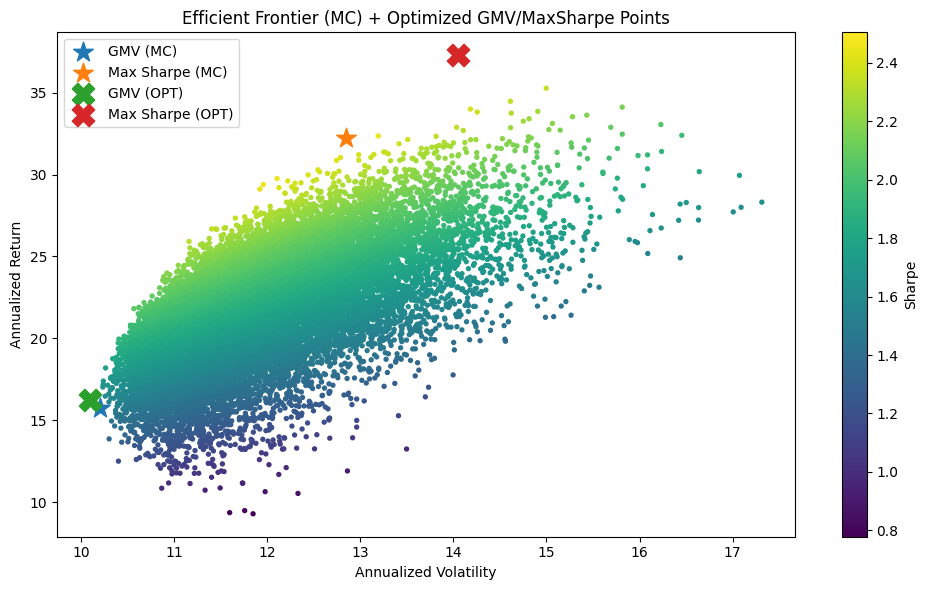

In [21]:
r_gmv_opt, v_gmv_opt, s_gmv_opt = perf_from_weights(w_gmv_opt, mu, cov)
r_ms_opt,  v_ms_opt,  s_ms_opt  = perf_from_weights(w_ms_opt,  mu, cov)

plt.figure(figsize=(10,6))
sc = plt.scatter(vols_mc, rets_mc, c=sharpes_mc, s=8)
plt.scatter(vols_mc[idx_gmv_mc], rets_mc[idx_gmv_mc], marker="*", s=220, label="GMV (MC)")
plt.scatter(vols_mc[idx_ms_mc],  rets_mc[idx_ms_mc],  marker="*", s=220, label="Max Sharpe (MC)")
plt.scatter(v_gmv_opt, r_gmv_opt, marker="X", s=260, label="GMV (OPT)")
plt.scatter(v_ms_opt,  r_ms_opt,  marker="X", s=260, label="Max Sharpe (OPT)")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier (MC) + Optimized GMV/MaxSharpe Points")
plt.colorbar(sc, label="Sharpe")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
def compute_metrics(daily_returns, rf_annual=RF_ANNUAL, trading_days=TRADING_DAYS):
    daily_returns = pd.Series(daily_returns).dropna()

    ann_ret = float(daily_returns.mean() * trading_days)
    ann_vol = float(daily_returns.std(ddof=1) * np.sqrt(trading_days))
    sharpe = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan

    # Sortino (downside deviation vs 0; you can also use rf_daily as threshold)
    downside = daily_returns[daily_returns < 0]
    downside_dev = float(downside.std(ddof=1) * np.sqrt(trading_days)) if len(downside) > 1 else np.nan
    sortino = (ann_ret - rf_annual) / downside_dev if downside_dev and downside_dev > 0 else np.nan

    equity = (1 + daily_returns).cumprod()
    peak = equity.cummax()
    max_dd = float(((equity / peak) - 1).min())  # negative

    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "AnnReturn": ann_ret,
        "AnnVol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MaxDrawdown": max_dd,
        "Calmar": calmar
    }

def portfolio_daily_returns(returns_df, w):
    return returns_df.values @ np.array(w)


In [23]:
w_equal = np.ones(n) / n

portfolios = {
    "EqualWeight": w_equal,
    "GMV_MC": w_gmv_mc,
    "MaxSharpe_MC": w_ms_mc,
    "GMV_OPT": w_gmv_opt,
    "MaxSharpe_OPT": w_ms_opt,
}

rows = []
for name, w in portfolios.items():
    train_p = portfolio_daily_returns(train, w)
    test_p  = portfolio_daily_returns(test,  w)

    m_train = compute_metrics(train_p)
    m_test  = compute_metrics(test_p)

    rows.append([name, "TRAIN", *m_train.values()])
    rows.append([name, "TEST",  *m_test.values()])

metrics_df = pd.DataFrame(rows, columns=["Portfolio","Split","AnnReturn","AnnVol","Sharpe","Sortino","MaxDrawdown","Calmar"])
display(metrics_df.sort_values(["Split","Sharpe"], ascending=[True, False]))


,Portfolio,Split,AnnReturn,AnnVol,Sharpe,Sortino,MaxDrawdown,Calmar
1,EqualWeight,TEST,5.859020,11.219512,0.516424,0.801748,-1.000175,5.857995
5,MaxSharpe_MC,TEST,6.840064,13.519305,0.501140,0.698838,-1.098217,6.228336
3,GMV_MC,TEST,3.991070,10.755148,0.365041,0.618694,-1.579958,2.526061
9,MaxSharpe_OPT,TEST,2.217179,14.829034,0.145133,0.196717,-1.074675,2.063116
7,GMV_OPT,TEST,1.115613,10.793290,0.097339,0.163181,-1.435244,0.777298
8,MaxSharpe_OPT,TRAIN,37.287731,14.048030,2.649676,4.012429,-1.008152,36.986205
4,MaxSharpe_MC,TRAIN,32.240384,12.844764,2.504942,3.838415,-1.092432,29.512490
0,EqualWeight,TRAIN,21.808054,11.259042,1.931164,2.887879,-1.001636,21.772442
6,GMV_OPT,TRAIN,16.217727,10.102335,1.598910,2.563222,-1.000010,16.217561
2,GMV_MC,TRAIN,15.727210,10.203749,1.534947,2.428426,-1.000027,15.726791


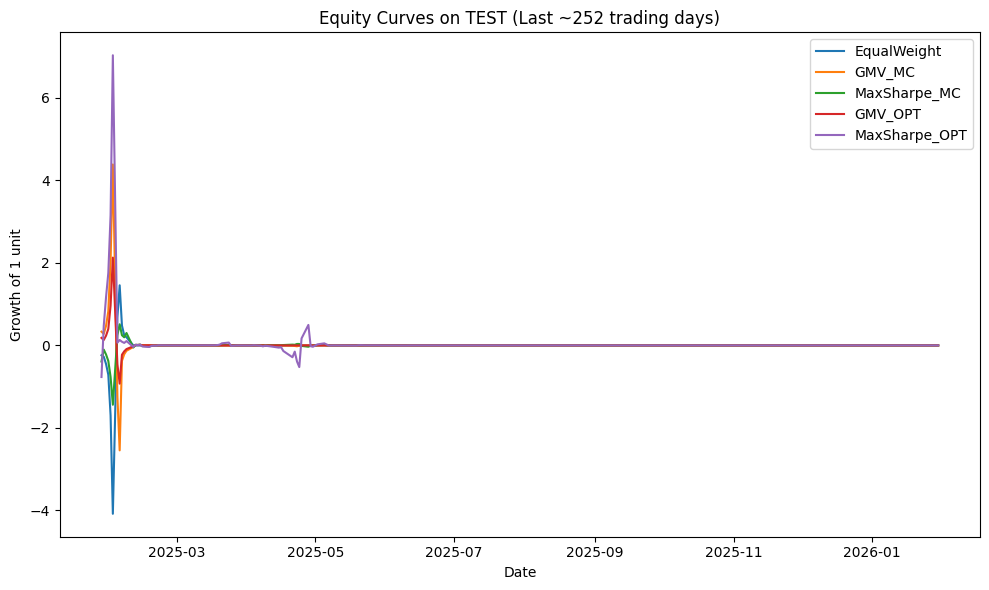

In [24]:
plt.figure(figsize=(10,6))
for name, w in portfolios.items():
    test_p = portfolio_daily_returns(test, w)
    eq = (1 + pd.Series(test_p, index=test.index)).cumprod()
    plt.plot(eq, label=name)

plt.title("Equity Curves on TEST (Last ~252 trading days)")
plt.xlabel("Date")
plt.ylabel("Growth of 1 unit")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
returns_10.describe().T[["min","max","mean","std"]]


,min,max,mean,std
HINDUNILVR,-7.4004,5.9595,0.003023,1.148318
SBIN,-14.4040,9.0685,0.114615,1.434597
CIPLA,-7.9316,9.6350,0.047749,1.443768
DMART,-8.5092,11.4674,0.018167,1.621008
INFY,-9.4227,7.9340,0.030647,1.504596
BAJAJ-AUTO,-12.8907,6.7204,0.145516,1.540097
INDUSTOWER,-15.3983,12.8089,0.177506,2.248385
ITC,-9.7146,5.4978,0.010528,1.151963
HDFCBANK,-8.4358,4.6287,0.029856,1.154501
SUNPHARMA,-4.5527,4.0179,0.071974,1.167186
